In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("screen_time_app_usage_dataset.csv")

df.head()

,user_id,date,app_name,category,screen_time_min,launches,interactions,is_productive,youtube_views,youtube_likes,...,extra_col_14,extra_col_15,extra_col_16,extra_col_17,extra_col_18,extra_col_19,extra_col_20,extra_col_21,extra_col_22,extra_col_23
0,1051,2024-01-01 00:00:00.000000000,Camera,Utilities,24.53,2,7,False,NaN,NaN,...,33.43,49.03,64.74,49.49,47.64,38.34,39.56,49.14,62.18,55.91
1,1088,2024-01-01 00:43:41.673891297,Chrome,Utilities,19.78,3,2,False,NaN,NaN,...,44.06,49.40,66.63,62.10,47.64,51.88,42.35,55.86,45.96,46.69
2,1052,2024-01-01 01:27:23.347782594,Spotify,Entertainment,32.03,1,6,False,NaN,NaN,...,55.18,41.87,54.84,65.59,61.28,49.51,41.11,55.53,44.13,71.01
3,1028,2024-01-01 02:11:05.021673891,Google Maps,Utilities,19.10,2,5,False,NaN,NaN,...,59.39,47.87,54.68,56.14,63.98,46.75,46.98,40.15,48.11,50.09
4,1034,2024-01-01 02:54:46.695565188,Instagram,Social,25.19,1,5,False,NaN,NaN,...,51.58,60.38,51.23,44.38,52.71,58.19,37.47,55.64,51.60,37.37


In [20]:
cols_to_drop = [col for col in df.columns if "extra_col" in col or "youtube" in col]
df = df.drop(columns=cols_to_drop, errors='ignore')


df = df.dropna()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   user_id          3000 non-null   int64  
 1   date             3000 non-null   object 
 2   app_name         3000 non-null   object 
 3   category         3000 non-null   object 
 4   screen_time_min  3000 non-null   float64
 5   launches         3000 non-null   int64  
 6   interactions     3000 non-null   int64  
 7   is_productive    3000 non-null   bool   
dtypes: bool(1), float64(1), int64(3), object(3)
memory usage: 167.1+ KB


In [5]:
df_user = df.groupby('user_id').agg({
    'screen_time_min': 'sum',
    'launches': 'sum',
    'interactions': 'sum',
    'is_productive': 'mean'
}).reset_index()

df_user.head()

,user_id,screen_time_min,launches,interactions,is_productive
0,1000,802.48,61,118,0.241379
1,1001,1276.70,64,192,0.305556
2,1002,854.67,63,131,0.200000
3,1003,1219.88,72,170,0.250000
4,1004,1052.38,66,163,0.266667


In [14]:
df_user['addiction_score'] = (
    df_user['screen_time_min'] * 0.4 +
    df_user['launches'] * 0.3 +
    df_user['interactions'] * 0.2 +
    (1 - df_user['is_productive']) * 200
)
df_user['addicted'] = (
    df_user['addiction_score'] > df_user['addiction_score'].median()
).astype(int)

In [6]:
df_user['addiction_score'] = (
    df_user['screen_time_min'] * 0.5 +
    df_user['launches'] * 0.2 +
    df_user['interactions'] * 0.2 -
    df_user['is_productive'] * 100
)

In [7]:
df_user['addicted'] = (
    df_user['addiction_score'] > df_user['addiction_score'].median()
).astype(int)

df_user.head()

,user_id,screen_time_min,launches,interactions,is_productive,addiction_score,addicted
0,1000,802.48,61,118,0.241379,412.902069,0
1,1001,1276.70,64,192,0.305556,658.994444,1
2,1002,854.67,63,131,0.200000,446.135000,0
3,1003,1219.88,72,170,0.250000,633.340000,1
4,1004,1052.38,66,163,0.266667,545.323333,1


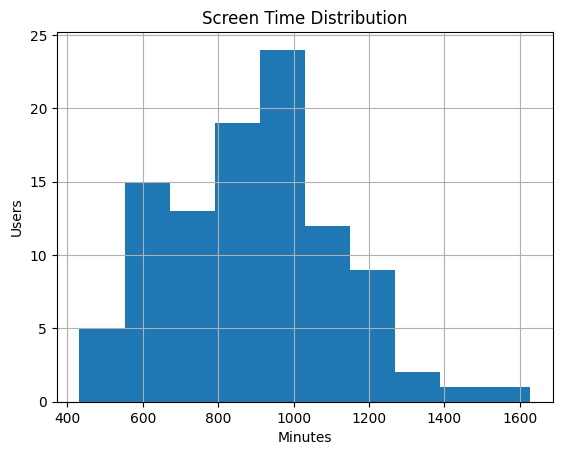

In [8]:
plt.figure()
df_user['screen_time_min'].hist()
plt.title("Screen Time Distribution")
plt.xlabel("Minutes")
plt.ylabel("Users")
plt.show()

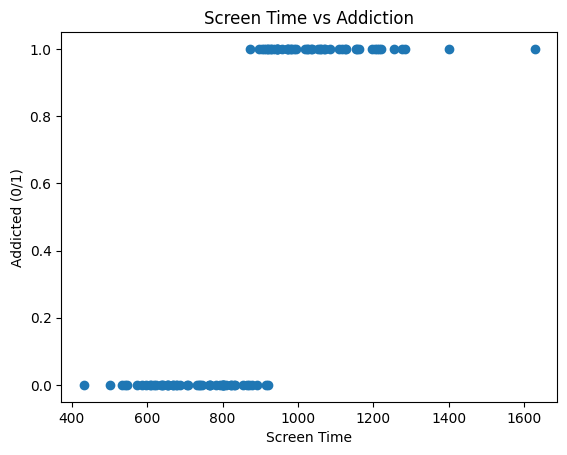

In [9]:
plt.figure()
plt.scatter(df_user['screen_time_min'], df_user['addicted'])
plt.title("Screen Time vs Addiction")
plt.xlabel("Screen Time")
plt.ylabel("Addicted (0/1)")
plt.show()

In [16]:
df_user['usage_type'] = df_user['is_productive'].apply(
    lambda x: "Productive" if x > 0.5 else "Distractive"
)

print(df_user.groupby('usage_type')['screen_time_min'].mean())

usage_type
Distractive    888.179901
Name: screen_time_min, dtype: float64


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = df_user[['screen_time_min', 'launches', 'interactions', 'is_productive']]
y = df_user['addicted']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [17]:
importance = model.coef_[0]
features = X.columns

for f, i in zip(features, importance):
    print(f, ":", i)

screen_time_min : 0.7635646417526619
launches : -0.49942194225341674
interactions : 0.5260729591444635
is_productive : -0.08185095799051798


In [11]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9523809523809523
              precision    recall  f1-score   support

           0       1.00      0.91      0.95        11
           1       0.91      1.00      0.95        10

    accuracy                           0.95        21
   macro avg       0.95      0.95      0.95        21
weighted avg       0.96      0.95      0.95        21



In [21]:
def suggest(row):
    if row['screen_time_min'] > 1000 and row['is_productive'] < 0.3:
        return "High risk: reduce usage + avoid social media"
    elif row['screen_time_min'] > 800:
        return "Moderate risk: cut down screen time"
    elif row['is_productive'] < 0.4:
        return "Increase productive app usage"
    else:
        return "Healthy usage"

df_user['suggestion'] = df_user.apply(suggest, axis=1)

df_user[['screen_time_min', 'is_productive', 'suggestion']].head()

,screen_time_min,is_productive,suggestion
0,802.48,0.241379,Moderate risk: cut down screen time
1,1276.70,0.305556,Moderate risk: cut down screen time
2,854.67,0.200000,Moderate risk: cut down screen time
3,1219.88,0.250000,High risk: reduce usage + avoid social media
4,1052.38,0.266667,High risk: reduce usage + avoid social media
